#Configuration

In [80]:
import numpy as np
import pandas as pd
import os

In [ ]:
import os

BASE_PATH = '...'
CSV_PATH  = os.path.join(BASE_PATH, 'wustl-scada-2018.csv')


In [83]:
df = pd.read_csv(CSV_PATH, low_memory=False, index_col=0)
df.replace([float('inf'), float('-inf')], float('nan'), inplace=True)

In [84]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sum())
print(df.describe())

(7037983, 6)
TotPkts     int64
TotBytes    int64
SrcPkts     int64
DstPkts     int64
SrcBytes    int64
Target      int64
dtype: object
0
            TotPkts      TotBytes       SrcPkts       DstPkts      SrcBytes  \
count  7.037983e+06  7.037983e+06  7.037983e+06  7.037983e+06  7.037983e+06   
mean   2.846016e+01  1.044996e+05  1.963329e+01  9.326535e+00  1.461540e+03   
std    9.658804e+02  1.186489e+07  9.658748e+02  5.385001e+01  6.987373e+04   
min    1.000000e+00  6.000000e+01  0.000000e+00  0.000000e+00  0.000000e+00   
25%    1.800000e+01  1.152000e+03  1.000000e+01  8.000000e+00  6.440000e+02   
50%    1.800000e+01  1.152000e+03  1.000000e+01  8.000000e+00  6.440000e+02   
75%    2.000000e+01  1.276000e+03  1.000000e+01  1.000000e+01  6.440000e+02   
max    2.261840e+05  2.144932e+09  2.261840e+05  4.265800e+04  1.615362e+07   

             Target  
count  7.037983e+06  
mean   5.731784e-02  
std    2.324490e-01  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00

In [85]:
# Cek distribusi label
label_col = df.columns[-1]
print(f"Label column: {label_col}")
print(df[label_col].value_counts())

Label column: Target
Target
0    6634581
1     403402
Name: count, dtype: int64


#Data Preprocessing

In [86]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 7037983
Total columns    : 6
Total missing    : 0
Affected columns : 0


In [87]:
label_col = 'Target'
exclude_cols = [label_col]

df_numeric = df.drop(columns=exclude_cols).select_dtypes(include=[np.number])
numeric_valid_cols = [col for col in df_numeric.columns if df_numeric[col].std() > 0]

# Verifikasi Target tidak ada
assert label_col not in numeric_valid_cols, "Target masih ada!"
print(f"Valid numeric features: {len(numeric_valid_cols)}")
print(numeric_valid_cols)

Valid numeric features: 5
['TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes']


In [88]:
import itertools
features = numeric_valid_cols
combinations = list(itertools.combinations(features, 2))
set_X = combinations[:len(combinations)//2]
set_Y = combinations[len(combinations)//2:]

print(f"Set X - ({len(set_X)} combination):")
for i, comb in enumerate(set_X, 1):
    print(f"  {i:2d}. {comb}")

print(f"\nSet Y - ({len(set_Y)} combination):")
for i, comb in enumerate(set_Y, 1):
    print(f"  {i:2d}. {comb}")

Set X - (5 combination):
   1. ('TotPkts', 'TotBytes')
   2. ('TotPkts', 'SrcPkts')
   3. ('TotPkts', 'DstPkts')
   4. ('TotPkts', 'SrcBytes')
   5. ('TotBytes', 'SrcPkts')

Set Y - (5 combination):
   1. ('TotBytes', 'DstPkts')
   2. ('TotBytes', 'SrcBytes')
   3. ('SrcPkts', 'DstPkts')
   4. ('SrcPkts', 'SrcBytes')
   5. ('DstPkts', 'SrcBytes')


In [89]:
import numpy as np
import pandas as pd
from scipy.linalg import fractional_matrix_power
import itertools

def manual_cca(X, Y, n_components=1):
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    if np.any(np.std(X, axis=0) == 0) or np.any(np.std(Y, axis=0) == 0):
        raise ValueError("Ada kolom dengan variansi nol.")

    Cxx = np.cov(X, rowvar=False)
    Cyy = np.cov(Y, rowvar=False)
    Cxy = np.cov(X.T, Y.T)[:X.shape[1], X.shape[1]:]

    reg = 1e-8
    Cxx += reg * np.eye(Cxx.shape[0])
    Cyy += reg * np.eye(Cyy.shape[0])

    Cxx_inv_sqrt = fractional_matrix_power(Cxx, -0.5)
    Cyy_inv_sqrt = fractional_matrix_power(Cyy, -0.5)

    M = Cxx_inv_sqrt @ Cxy @ Cyy_inv_sqrt
    U, s, Vt = np.linalg.svd(M)

    wx = Cxx_inv_sqrt @ U[:, :n_components]
    wy = Cyy_inv_sqrt @ Vt.T[:, :n_components]

    return s[:n_components], wx, wy

cca_results = []

for i, (pair_x, pair_y) in enumerate(zip(set_X, set_Y)):
    try:
        X_pair = df[list(pair_x)].to_numpy()
        Y_pair = df[list(pair_y)].to_numpy()

        corr, _, _ = manual_cca(X_pair, Y_pair, n_components=1)

        cca_results.append({
            "Pair": f"Pair-{i+1}",
            "Feature_X": pair_x,
            "Feature_Y": pair_y,
            "Canonical_Correlation": corr[0]
        })

    except Exception as e:
        print(f"Failed CCA-{i+1} ({pair_x} vs {pair_y}): {e}")

df_cca = pd.DataFrame(cca_results)
df_cca_sorted = df_cca.sort_values(by='Canonical_Correlation', ascending=False)

print("\nTop 10 highest  canonical correlation:")
print(df_cca_sorted.head(20))



Top 10 highest  canonical correlation:
     Pair            Feature_X             Feature_Y  Canonical_Correlation
0  Pair-1  (TotPkts, TotBytes)   (TotBytes, DstPkts)               1.000000
3  Pair-4  (TotPkts, SrcBytes)   (SrcPkts, SrcBytes)               1.000000
2  Pair-3   (TotPkts, DstPkts)    (SrcPkts, DstPkts)               1.000000
1  Pair-2   (TotPkts, SrcPkts)  (TotBytes, SrcBytes)               0.999935
4  Pair-5  (TotBytes, SrcPkts)   (DstPkts, SrcBytes)               0.999425


In [90]:
print(df['Target'].dtype)
print(df['Target'].unique())

int64
[0 1]


/tmp/ipykernel_2923/2830772401.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_feature_freq, x='Feature', y='Frequency', palette='magma')


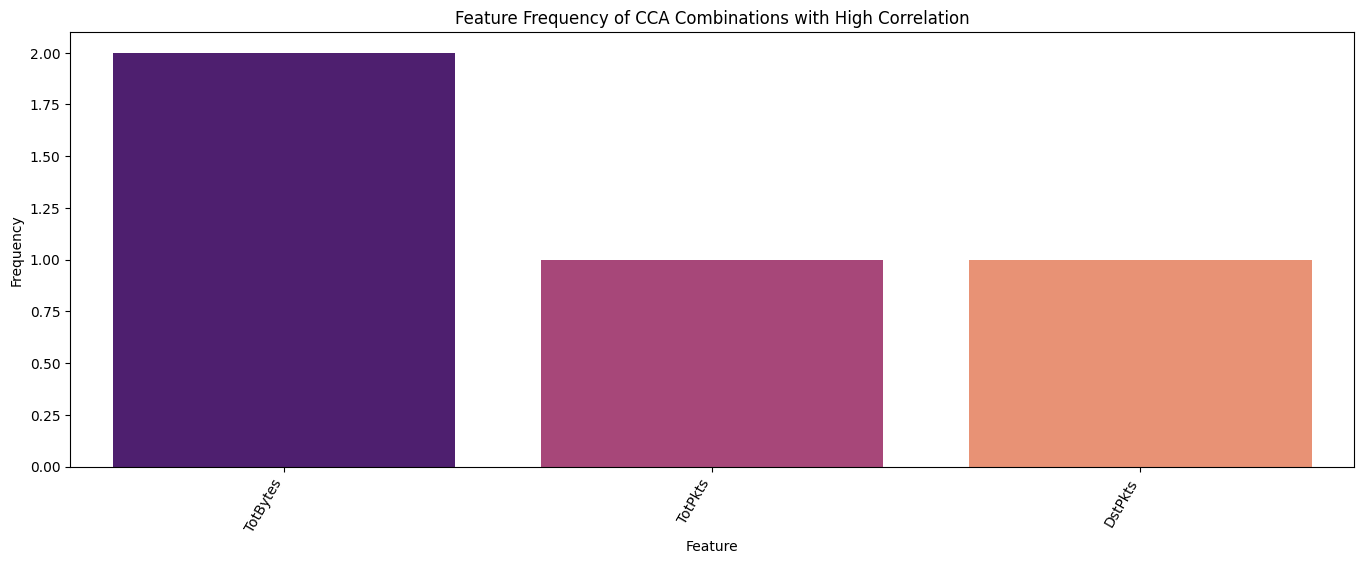

In [91]:
from collections import Counter
threshold = df_cca_sorted['Canonical_Correlation'].quantile(0.9)
df_filtered = df_cca_sorted[df_cca_sorted['Canonical_Correlation'] >= threshold]
all_features = []

for _, row in df_filtered.iterrows():
    all_features.extend(row['Feature_X'])
    all_features.extend(row['Feature_Y'])

feature_counts = Counter(all_features)

df_feature_freq = pd.DataFrame(feature_counts.items(), columns=['Feature', 'Frequency'])
df_feature_freq = df_feature_freq.sort_values(by='Frequency', ascending=False)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.barplot(data=df_feature_freq, x='Feature', y='Frequency', palette='magma')

plt.title("Feature Frequency of CCA Combinations with High Correlation")
plt.xlabel("Feature")
plt.ylabel("Frequency")
plt.xticks(rotation=60, ha='right')
plt.tight_layout(pad=2.0)

plt.show()